# 의료비 예측 MLP 회귀 모델

실습순서
- Kaggle 에서 데이터(csv) 다운로드  
    - https://www.kaggle.com/datasets/mirichoi0218/insurance  
- 수치형 / 범주형 데이터 확인  
- train / valid / test 데이터 분리  
- 수치형 정규화 / 범주형 One-Hot Encoding  
- target 값 로그 변환 및 표준화  
- Pytorch Tensor형태로 데이터 변환  
- Dataset / Loader로 미니배치 학습 준비  
- 다층 퍼셉트론(MLP) 회귀 모델 설계  
    - BatchNorm, Dropout, SiLU 활성화 함수 사용  
- HuberLoss 손실함수, AdamW 최적화 함수, Scheduler, Gradient Clipping, EarlyStopping  
- 학습 및 검증  
- 지표 확인 / 시각화  
- Test 데이터로 모델 최종 확인  
- 임의의 데이터로 테스트  


1. 라이브러리 import  

In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn # 신경망 구성 및 손실함수
from torch.utils.data import TensorDataset, DataLoader # Tensor 데이터셋 / 미니배치 로더

import kagglehub # 캐글 허브
from tqdm.auto import tqdm # 프로그래스바

from sklearn.model_selection import train_test_split, KFold # 데이터 분리 / K-Fold 검증
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline     # 전처리 과정 통합
from sklearn.impute import SimpleImputer  # 결측치 처리
from sklearn.preprocessing import StandardScaler,OneHotEncoder # 표준화
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False


c:\Workspace\DL\dl_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 시드값 고정, CPU/GPU 사용 장치 설정
SEED = 42

random.seed(SEED)      # 파이썬 랜덤 시드 고정
np.random.seed(SEED)   # numpy 랜덤 시드 고정
torch.manual_seed(SEED)# Pytorch CPU 랜덤 시드 고정
torch.cuda.manual_seed_all(SEED)# Pytorch CPU 랜덤 시드 고정

# GPU 가용시 device = 'cuda', 아니면 'cpu'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [3]:
path = path = kagglehub.dataset_download("mirichoi0218/insurance",path="insurance.csv")

df = pd.read_csv(path)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

컬럼 설명
- age : 나이
- sex : 성별
- bmi : 체질량지수
- children : 부양 자녀 수
- smoker : 흡연 여부
- region : 거주 지역
charges : 의료비 청구 금액 (target)

In [5]:
print(df.shape)

df.info()

(1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [8]:
categorical_cols = ['sex','smoker','region']
for col in categorical_cols:
    print(df[col].value_counts()) # 범주형 값 갯수

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


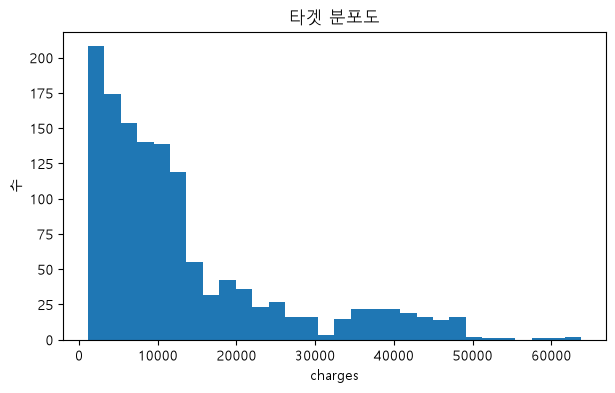

In [9]:
# target컬럼 분포도
plt.figure(figsize=(7,4))
plt.hist(df['charges'],bins=30)
plt.title("타겟 분포도")
plt.xlabel("charges")
plt.ylabel("수")
plt.show()

<Figure size 700x400 with 0 Axes>

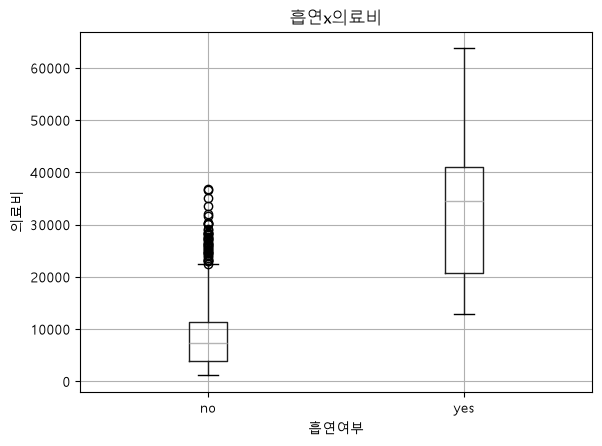

In [10]:
# target컬럼 분포도
plt.figure(figsize=(7,4))
df.boxplot(column='charges', by='smoker') # 흡연여부별 의료비 boxplot
plt.title("흡연x의료비")
plt.suptitle("")       # 기존 자동생성 상위제목 제거
plt.xlabel("흡연여부")
plt.ylabel("의료비")
plt.show()

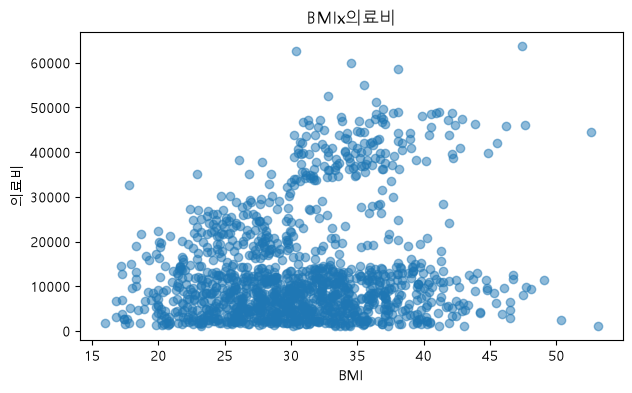

In [11]:
# target컬럼 분포도
plt.figure(figsize=(7,4))
plt.scatter(df['bmi'],df['charges'], alpha=0.5) # BMI와 의료비 관계 산점도
plt.title("BMIx의료비")
plt.xlabel("BMI")
plt.ylabel("의료비")
plt.show()

3. 입력 데이터와 정답 데이터 분리

In [12]:
X = df.drop(columns='charges')
y = df['charges']

print(X.shape,y.shape)

(1338, 6) (1338,)


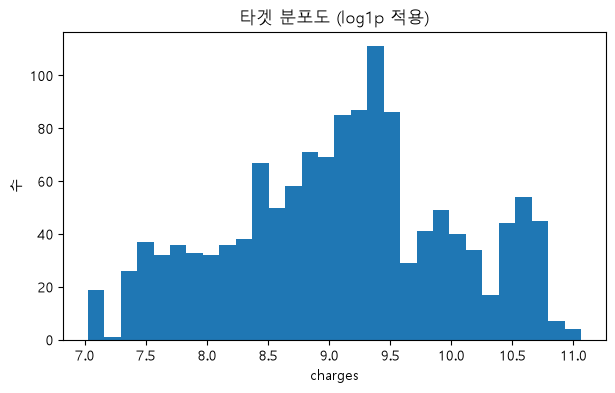

In [13]:
# target 컬럼이 왼쪽으로 치우친 형태이므로 로그 변환 적용
y_log = np.log1p(y)

# target컬럼 분포도
plt.figure(figsize=(7,4))
plt.hist(y_log,bins=30)
plt.title("타겟 분포도 (log1p 적용)")
plt.xlabel("charges")
plt.ylabel("수")
plt.show()

log 변환 적용해주니 정규분포와 가까워진 형태로 변환됨

4. train / valid / test 데이터 분리

In [14]:
# test 데이터를 8:2 비율로 나눈다.
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X,y_log,
    test_size=0.2,
    random_state=SEED,
)

# 남은 80% 중 8:2 비율로 train / valid 데이터를 나눈다.
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid,y_train_valid,
    test_size=0.2,
    random_state=SEED,
)

print(f"X_train : {X_train.shape}, X_valid : {X_valid.shape}, X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}, y_valid : {y_valid.shape}, y_test : {y_test.shape}")

X_train : (856, 6), X_valid : (214, 6), X_test : (268, 6)
y_train : (856,), y_valid : (214,), y_test : (268,)


5. 전처리 Pipeline 구성
- 수치형 : 정규화
- 범주형 : One-Hot Encoding

In [15]:
# 범주형, 수치형 컬럼 구분
categorical_features = ['sex', 'smoker', 'region']
numeric_features = ['age','bmi','children']

onehot_encoder = OneHotEncoder(
    handle_unknown='ignore', # 학습시 없던 범주가 입력되어도 오류 없이 무시
    sparse_output=False      # True : 희소 행렬, False : 일반 Numpy 배열로 반환
)
# 수치형 전처리 : 결측값 중앙값 대체 표준화
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler", StandardScaler())
])
# 범주형 전처리 : 결측값 최빈값 대체 원핫인코딩
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ("onehot", onehot_encoder)
])
# 컬럼별 전처리 통합
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline,numeric_features), # 수치형 컬럼에는 수치형 전처리
    ("category", categorical_pipeline, categorical_features) # 범주형 컬럼에는 범주형 전처리
])

In [16]:
# preprocessor 전처리 도구로 학습 및 변환
X_train_scaled = preprocessor.fit_transform(X_train)
X_valid_scaled = preprocessor.transform(X_valid)
X_test_scaled = preprocessor.transform(X_test)

print(X_train_scaled.shape, X_valid_scaled.shape, X_test_scaled.shape)

(856, 11) (214, 11) (268, 11)


In [17]:
y_mean = y_train.mean()
y_std = y_train.std()

y_train_scaled = (y_train - y_mean) / y_std
y_valid_scaled = (y_valid - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

print(f"target mean : {y_mean}, target std : {y_std}") # 표준화에 사용한 평균, 표준편차

target mean : 9.104843701853595, target std : 0.9082830243269455


실제 테스트 데이터로 결과 확인할 때는 결과로 나온 y값을 

6. Pytorch Tensor 변환

In [18]:
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_valid_tensor = torch.FloatTensor(X_valid_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

y_train_tensor = torch.FloatTensor(y_train_scaled.to_numpy()).reshape(-1,1)
y_valid_tensor = torch.FloatTensor(y_valid_scaled.to_numpy()).reshape(-1,1)
y_test_tensor = torch.FloatTensor(y_test_scaled.to_numpy()).reshape(-1,1)

print(X_train_tensor.size(), X_valid_tensor.size(), X_test_tensor.size())
print(y_train_tensor.size(), y_valid_tensor.size(), y_test_tensor.size())

torch.Size([856, 11]) torch.Size([214, 11]) torch.Size([268, 11])
torch.Size([856, 1]) torch.Size([214, 1]) torch.Size([268, 1])


C:\Users\lsm15\AppData\Local\Temp\ipykernel_37356\173125100.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train_tensor = torch.FloatTensor(y_train_scaled.to_numpy()).reshape(-1,1)


7. TensorDataset / DataLoader로 미니배치 데이터 준비


In [19]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor,y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(len(train_loader),len(valid_loader),len(test_loader))

27 7 9


8. 다층 퍼셉트론 회귀 모델 설계

In [20]:
class RegressionMLP(nn.Module):

    def __init__(self, input_dim, hidden_dims=(128,64,32), dropout=0.2):
        super().__init__() # 부모 클래스 초기화

        layers = [] # 신경망 계층을 모두 저장할 리스트
        prev_dim = input_dim # 이전 계층의 출력 차원

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim)) # 배치 정규화 (평균 0, 표준편차 1) : 수치 안정화 -> 학습 안정화
            # 활성화 함수 추가 (비선형성 추가)
            layers.append(nn.SiLU())
            layers.append(nn.Dropout(dropout)) # 일부 파라미터 생략 (과적합 완화)
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1)) # 이진 분류 출력층
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [21]:
input_dim = X_train_tensor.size(-1)

model = RegressionMLP(input_dim= input_dim).to(device)

model

RegressionMLP(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

9. 손실함수, Optimizer, Scheduler 설정

In [22]:
#HuberLoss 손실함수 : 작은 오차는 MSE, 큰 오차는 MAE 방식으로 작동한다.
criterion = nn.HuberLoss(delta=1.0)

# AdamW 최적화함수 : Adam + weight_decay(가중치 감쇠)로 안정적인 학습
optimizer = torch.optim.AdamW(
    model.parameters(),  # 학습할 모델 파라미터
    lr = 0.001,          # 학습률
    weight_decay= 0.01   # 가중치 감쇠율 (과적합 완화)
)

# val_loss 기준으로 일저 epoch동안 개선없을시 학습률 감소
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,     # 조절할 최적화함수
    mode = 'min',  # validation_loss는 최소화해야되므로 min
    factor = 0.5,  # 감소 비율
    patience = 5   # 5 epoch 동안 인내
)

10. EarlyStopping
- validation_loss가 일정 epoch동안 개선없으면 학습 종료
- 과적합 완화 목적



In [23]:
class EarlyStopping():
    def __init__(self, patience=20, min_delta=0.0):
        self.patience = patience   # 개선이 없을때 기다릴 epoch 수
        self.min_delta = min_delta # 개선으로 인정할 최소 손실 감소량
        self.best_loss = np.inf    # 현재까지 가장 낮은 valid loss
        self.counter = 0           # 개선이 없던 epoch 수
        self.best_state = None     # 가장 성능이 좋은 모델의 가중치
        self.should_stop = False   # 학습 중단 여부 플래그

    def step(self, valid_loss, model):
        # 최소 손실 갱신시
        if valid_loss < self.best_loss - self.min_delta:
            self.best_loss = valid_loss
            self.counter = 0

            self.best_state = {
                key : value.detach().cpu().clone() for key, value in model.state_dict().items()
                }
        else:
            self.counter+=1
            if self.counter >=self.patience:
                self.should_stop = True

11. 학습 및 검증
- 학습
1. 예측값 계산
2. 손실 계산
3. 기존 기울기 초기화
4. 오차역전파 : 기울기 계산
5. Gridient Clipping : 기울기 폭주 방지
6. 가중치 업데이트

In [24]:
def train_one_epoch(model, data_lodaer, criterion, optimizer, device):
    model.train()  # 학습 모드
    total_loss = 0 # 전체 손실

    for X_batch, y_batch in data_lodaer:
        X_batch = X_batch.to(device) # 입력 데이터를 CPU/GPU로 이동
        y_batch = y_batch.to(device) # 출력 데이터를 CPU/GPU로 이동

        optimizer.zero_grad() # 이전 step 기울기 초기화
        output = model(X_batch) # 예측값 계산
        loss = criterion(output, y_batch) # 손실 계산

        loss.backward() # 기울기 계산
        # Gridient Clipping(기울기 폭주 방지)
        nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step() # 가중치 업데이트

        total_loss += loss.item() * len(X_batch) # 배치 손실을 데이터 수만큼 누적

    return total_loss / len(data_lodaer.dataset) # 데이터 1개당 평균 손실 반환

def evalute_loss(model, data_lodaer, criterion, device):
    model.eval() # 평가 모드
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in data_lodaer:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            output = model(X_batch)
            loss = criterion(output,y_batch)

            total_loss += loss.item() * len(X_batch)

    return total_loss / len(data_lodaer.dataset)

12. 모델 학습

In [25]:
EPOCHS = 150

early_stopping = EarlyStopping(patience=20, min_delta=0.0001)
max_grad_norm = 0.3
history = {
    'train_loss': [],
    'valid_loss': [],
    'lr':[]
}

for epoch in tqdm(range(EPOCHS), desc='Traing'):
    train_loss = train_one_epoch(model, train_loader,criterion,optimizer,device)
    valid_loss = evalute_loss(model, valid_loader, criterion,device)

    scheduler.step(valid_loss)

    current_lr = optimizer.param_groups[0]['lr'] # 현재 학습률 화인

    history['train_loss'].append(train_loss)
    history['valid_loss'].append(valid_loss)
    history['lr'].append(current_lr)
    
    early_stopping.step(valid_loss, model)

    # 20번 동안 개선이 없을시 flag True가 되면
    if early_stopping.should_stop:
        print(f"Epoch : {epoch + 1}에서 학습 중지")
        break

if early_stopping.best_state is not None:
    # 가장 성능이 좋은 모델의 가중치 복원
    model.load_state_dict(early_stopping.best_state)

history_df = pd.DataFrame(history)

Traing:  34%|███▍      | 51/150 [00:10<00:20,  4.91it/s]

Epoch : 52에서 학습 중지


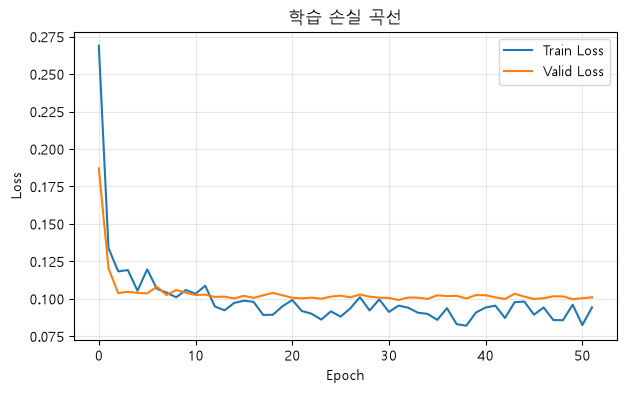

In [26]:
# 학습 / 검증 손실 곡선
plt.figure(figsize=(7,4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["valid_loss"], label="Valid Loss")
plt.title("학습 손실 곡선")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

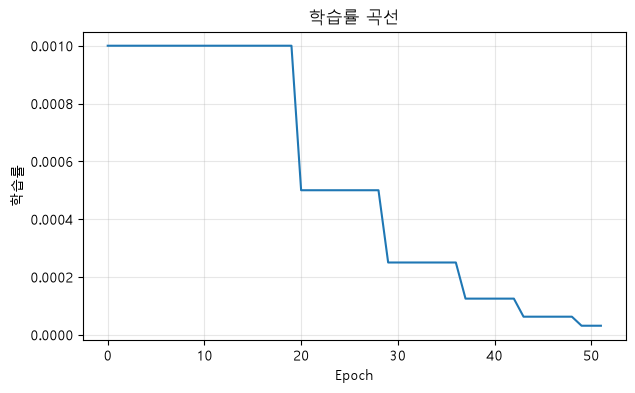

In [27]:
# 학습률 곡선 시각화
plt.figure(figsize=(7, 4))
plt.plot(history["lr"])
plt.title("학습률 곡선")
plt.xlabel("Epoch")
plt.ylabel("학습률")
plt.grid(alpha=0.3)  # 격자
plt.show()

14. 테스트 데이터로 최종 평가

In [28]:
# 타겟값을 역변환 시켜주는 함수
def inverse_target(y_scaled):
    y_log_restored = y_scaled * y_std + y_mean

    return np.expm1(y_log_restored)

def predict_loader(model, data_loader, device):
    model.eval()      # 평가 모드
    preds = []        # 예측값
    target_list = []  # 정답

    # 예측시 기울기 계산 비활성화
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)  # 입력 데이터만 장치로 이동
            output = model(X_batch)

            preds.append(output.cpu().numpy()) # 예측값을 CPU Numpy로 변환해 저장
            target_list.append(y_batch.numpy())

    preds = np.vstack(preds).ravel() # 예측값을 1차원으로 변환
    y_true = np.vstack(target_list).ravel() # 정답을 1차원으로 변환
    return preds, y_true

In [29]:
test_pred_scaled, test_true_scaled = predict_loader(model, test_loader, device)
test_pred = inverse_target(test_pred_scaled)
test_true = inverse_target(test_true_scaled)

mae = mean_absolute_error(test_true, test_pred)
rmse = np.sqrt(mean_squared_error(test_true, test_pred))
r2 = r2_score(test_true,test_pred)

print(f"{mae}")
print(f"{rmse}")
print(f"{r2}")

2256.63522261301
4507.078623523645
0.869153470972125


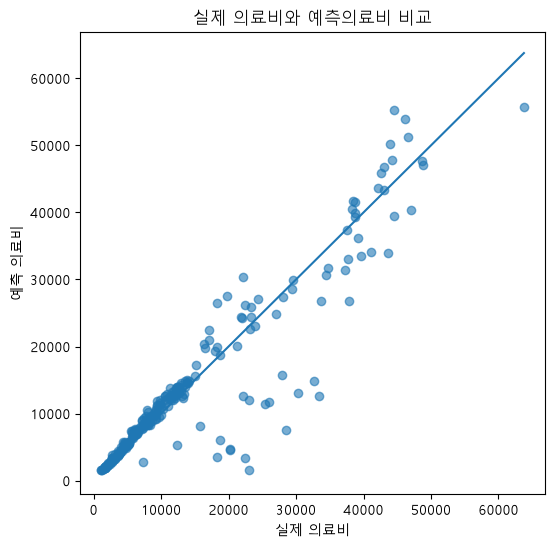

In [30]:
# 실제값과 예측값 비교 그래프 시각화
plt.figure(figsize=(6,6))
plt.scatter(test_true, test_pred, alpha=0.6)
# 완벽한 실제값 절대선 : 예측이 완벽하게 되면 이 대각선 가까이에 점들이 위치
plt.plot([test_true.min(), test_true.max()],
         [test_true.min(), test_true.max()])
plt.title("실제 의료비와 예측의료비 비교")
plt.xlabel("실제 의료비")
plt.ylabel("예측 의료비")
plt.show()

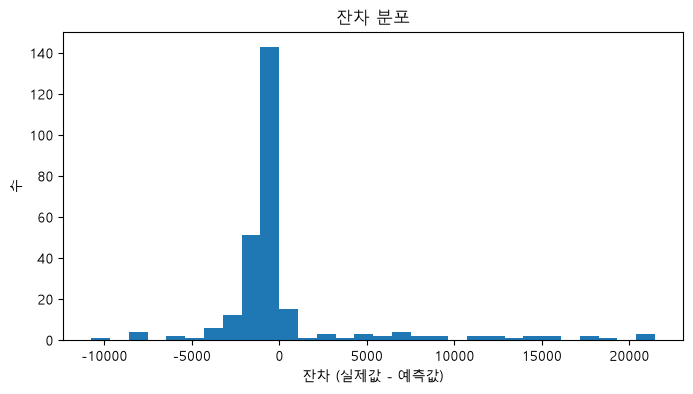

In [31]:
# 잔차 : 실제값과 예측값 차이 시각화
residuals = test_true - test_pred
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=30)
plt.title("잔차 분포")
plt.xlabel("잔차 (실제값 - 예측값)")
plt.ylabel("수")
plt.show()

In [32]:
result_df = pd.DataFrame({
    "actual" : test_true,
    "predicted" : test_pred,
    "error" : test_true - test_pred
})
print(result_df)

           actual     predicted        error
0     5757.413442   7459.377557 -1701.964114
1     4349.461965   4767.657474  -418.195509
2     1256.298965   1596.353349  -340.054384
3    24393.623618  27052.153858 -2658.530240
4     8017.061169   8253.885759  -236.824590
..            ...           ...          ...
263  11674.129974  13242.829588 -1568.699614
264   8569.861792   9539.332549  -969.470757
265  13415.038121  12929.673662   485.364459
266  16577.779508  19751.619724 -3173.840215
267  23306.547987  25827.601368 -2521.053381

[268 rows x 3 columns]


15. 임의의 데이터로 테스트

In [33]:
# 새로운 데이터 예측 함수
def predict_charge(new_data, model, preprocessor, device):
    new_scaled = preprocessor.transform(new_data) # 학습 전처리 기준으로 전처리

    new_tensor = torch.FloatTensor(new_scaled).to(device) # tenspr 변환

    model.eval() # 평가 모드 (Batch Nor, Droput 비활성화)
    with torch.no_grad(): # 평가시에는 계산 비활성화
        pred_scaled = model(new_tensor).cpu().numpy().ravel() # 1차원으로 의료비 예측 (평탄화)

    pred_charge = inverse_target(pred_scaled) # 원래 수치 단위로 복원
    return pred_charge

In [34]:
# 샘플데이터 (컬럼명을 학습데이터와 동일하게 구성)
sample_data = pd.DataFrame([
    {
        'age' :35,
        'sex' : 'male',
        'bmi' : 27.5,
        'children' : 1,
        'smoker' : 'no',
        'region' : 'southest'
    },

    {
        'age' :50,
        'sex' : 'female',
        'bmi' : 32.0,
        'children' : 2,
        'smoker' : 'yes',
        'region' : 'northwest'
    },
])

predicted_charge = predict_charge(sample_data, model, preprocessor, device)
predicted_charge

array([ 5246.67512461, 37439.48945222])